In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
number = np.random.uniform(-1,1,(50000,2))

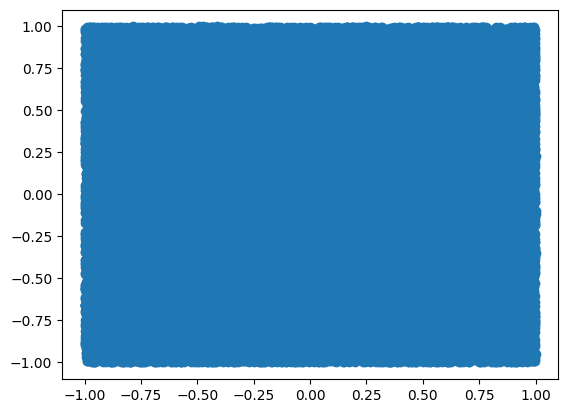

In [3]:
plt.scatter(number[:,0], number[:,1])
plt.show()

In [4]:
y = ((number[:,0]*number[:,0])+(number[:,1]*number[:,1])) <= 1.0
y.astype(int)

array([1, 0, 1, ..., 1, 1, 1], shape=(50000,))

In [5]:
import torch
import torch.nn as nn

In [6]:
X = torch.tensor(number, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).view(-1,1)

In [7]:
print(X.shape)
print(y.shape)

torch.Size([50000, 2])
torch.Size([50000, 1])


In [8]:
class PiNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.s1 = nn.Linear(2, 32)
        self.s2 = nn.Linear(32, 32)
        self.s3 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.s1(x)
        x = torch.relu(x)
        x = self.s2(x)
        x = torch.relu(x)
        x = self.s3(x)
        x = torch.sigmoid(x)
        return x

model = PiNet()
print(model)

PiNet(
  (s1): Linear(in_features=2, out_features=32, bias=True)
  (s2): Linear(in_features=32, out_features=32, bias=True)
  (s3): Linear(in_features=32, out_features=1, bias=True)
)


In [9]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [10]:
for epoch in range(3000):
    predictions = model(X)
    loss = criterion(predictions, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f"Epoche {epoch:3d} | Aktueller Loss: {loss.item():.4f}")

Epoche   0 | Aktueller Loss: 0.7011
Epoche 100 | Aktueller Loss: 0.0653
Epoche 200 | Aktueller Loss: 0.0309
Epoche 300 | Aktueller Loss: 0.0217
Epoche 400 | Aktueller Loss: 0.0179
Epoche 500 | Aktueller Loss: 0.0151
Epoche 600 | Aktueller Loss: 0.0135
Epoche 700 | Aktueller Loss: 0.0123
Epoche 800 | Aktueller Loss: 0.0114
Epoche 900 | Aktueller Loss: 0.0107
Epoche 1000 | Aktueller Loss: 0.0101
Epoche 1100 | Aktueller Loss: 0.0095
Epoche 1200 | Aktueller Loss: 0.0090
Epoche 1300 | Aktueller Loss: 0.0087
Epoche 1400 | Aktueller Loss: 0.0085
Epoche 1500 | Aktueller Loss: 0.0081
Epoche 1600 | Aktueller Loss: 0.0078
Epoche 1700 | Aktueller Loss: 0.0076
Epoche 1800 | Aktueller Loss: 0.0074
Epoche 1900 | Aktueller Loss: 0.0072
Epoche 2000 | Aktueller Loss: 0.0076
Epoche 2100 | Aktueller Loss: 0.0069
Epoche 2200 | Aktueller Loss: 0.0069
Epoche 2300 | Aktueller Loss: 0.0066
Epoche 2400 | Aktueller Loss: 0.0068
Epoche 2500 | Aktueller Loss: 0.0064
Epoche 2600 | Aktueller Loss: 0.0063
Epoche 2700

In [11]:
number = np.random.uniform(-1,1,(100000,2))
X_test = torch.tensor(number, dtype=torch.float32)

with torch.no_grad():
    pre = model(X_test)
    hit = (pre >= 0.5).sum().item()

pi = 4 * (hit/100000)
print(f"PI: {pi:f}")

PI: 3.145720
